In [142]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import xgboost as xgb

from catboost import CatBoostClassifier



In [105]:
X_train = pd.read_csv('data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('data/y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('data/sample_submission.csv',index_col='ROW_ID')

# Features

In [107]:
ret_cols = [c for c in X_test.columns if c.startswith("RET_")]
vol_cols = [c for c in X_test.columns if c.startswith("SIGNED_VOLUME_")]

def fillna_row_mean(df, cols):
    A = df[cols].to_numpy(dtype=float)
    m = np.isnan(A)
    if m.any():
        row_mean = np.nanmean(A, axis=1)
        # si une ligne est full-NaN (rare), remplace la "moyenne" NaN par 0
        row_mean = np.where(np.isfinite(row_mean), row_mean, 0.0)
        r, c = np.where(m)
        A[r, c] = row_mean[r]
        df.loc[:, cols] = A
    return df

X_test = fillna_row_mean(X_test, ret_cols)
X_test = fillna_row_mean(X_test, vol_cols)

In [108]:
RET_features = [f'RET_{i}' for i in range(1,20)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,20)]
TURNOVER_features = ['AVG_DAILY_TURNOVER']

In [109]:
for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i+1]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i+1]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

In [110]:
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]

EMA

In [111]:
ret_cols = [f"RET_{i}" for i in range(1, 21)]
r = X_train[ret_cols].to_numpy()

rtest = X_test[ret_cols].to_numpy()

def ema(arr, L):
    alpha = 2/(L+1)
    w = (1-alpha) ** np.arange(L)  # 0..L-1
    w = w / w.sum()
    return (arr[:, :L] * w).sum(axis=1)

X_train["ema3"]  = ema(r, 3)
X_train["ema5"]  = ema(r, 5)
X_train["ema10"] = ema(r,10)


X_test["ema3"]  = ema(rtest, 3)
X_test["ema5"]  = ema(rtest, 5)
X_test["ema10"] = ema(rtest,10)

m20 = r.mean(axis=1)
s20 = r.std(axis=1, ddof=0)

m20test = rtest.mean(axis=1)
s20test = rtest.std(axis=1, ddof=0)

X_train["z20"] = m20 / (s20 + 1e-12)
X_test["z20"] = m20test / (s20test + 1e-12)

Streak de signe et entropie 

In [112]:
sign = np.sign(r)  
signtest = np.sign(rtest)

def last_streak_len(sig_row, positive=True):
    # part de RET_1 vers RET_20
    target = 1 if positive else -1
    cnt = 0
    for v in sig_row[:20]:  # [:20] explicite
        if v == target:
            cnt += 1
        else:
            break
    return cnt

X_train["streak_pos"] = [last_streak_len(s, True) for s in sign]
X_train["streak_neg"] = [last_streak_len(s, False) for s in sign]

X_test["streak_pos"] = [last_streak_len(s, True) for s in signtest]
X_test["streak_neg"] = [last_streak_len(s, False) for s in signtest]

p = (r > 0).mean(axis=1)
p = np.clip(p, 1e-9, 1 - 1e-9)
X_train["sign_entropy20"] = -(p*np.log(p) + (1-p)*np.log(1-p))

ptest = (rtest > 0).mean(axis=1)    
ptest = np.clip(ptest, 1e-9, 1 - 1e-9)
X_test["sign_entropy20"] = -(ptest*np.log(ptest) + (1-ptest)*np.log(1-ptest))


Qualité de rendement (Sharpe10, Sortino10, t-stat(mean10))

In [99]:
r10 = r[:, :10]
m10 = r10.mean(axis=1)
s10 = r10.std(axis=1, ddof=0)
neg10 = np.minimum(r10, 0)

r10test = rtest[:, :10]
m10test = r10test.mean(axis=1)
s10test = r10test.std(axis=1, ddof=0)
neg10test = np.minimum(r10test, 0)

X_train["sharpe10"]   = m10 / (s10 + 1e-12)
downside10 = np.sqrt((neg10**2).mean(axis=1))
X_train["sortino10"]  = m10 / (downside10 + 1e-12)
X_train["tstat_mean10"] = m10 / (s10/np.sqrt(10) + 1e-12)

X_test["sharpe10"]   = m10test / (s10test + 1e-12)
downside10test = np.sqrt((neg10test**2).mean(axis=1))
X_test["sortino10"]  = m10test / (downside10test + 1e-12)
X_test["tstat_mean10"] = m10test / (s10test/np.sqrt(10) + 1e-12)


In [100]:
X_train["vol10"]         = s10
X_train["downside_dev10"]= downside10

X_test["vol10"]         = s10test
X_test["downside_dev10"]= downside10test

def maxdd_and_recovery(row):
    c = np.cumsum(row)                   # equity curve 20j
    peak = np.maximum.accumulate(c)
    dd = (c - peak)
    maxdd = dd.min()                     # drawdown (négatif)
    # recovery: jours depuis le dernier pic
    last_peak_idx = np.where(c == peak)[0][-1]
    recovery = 20 - 1 - last_peak_idx
    return maxdd, recovery

md_rec = np.apply_along_axis(maxdd_and_recovery, 1, r)
X_train["maxdd20"]   = md_rec[:,0]
X_train["recovery20"]= md_rec[:,1]

md_rec_test = np.apply_along_axis(maxdd_and_recovery, 1, rtest)
X_test["maxdd20"]    = md_rec_test[:,0]
X_test["recovery20"] = md_rec_test[:,1]


Liquidity / turnover (moyenne/écart-type volumes, autocorr, corr ret–liq ; turnover moyen)

In [113]:

ret_cols = [f"RET_{i}" for i in range(1, 21)]
vol_cols = [f"SIGNED_VOLUME_{i}" for i in range(1, 21)]
EPS = 1e-12

def add_volume_features(X):
    v = np.nan_to_num(X[vol_cols].to_numpy(), nan=0.0)
    r = np.nan_to_num(X[ret_cols].to_numpy(), nan=0.0)

    X["sv_mean20"] = v.mean(axis=1)
    X["sv_std20"]  = v.std(axis=1, ddof=0)

    v_mean = v.mean(axis=1, keepdims=True)
    vx = v - v_mean
    num = (vx[:,1:] * vx[:,:-1]).sum(axis=1)
    den = np.sqrt((vx[:,1:]**2).sum(axis=1) * (vx[:,:-1]**2).sum(axis=1))
    X["sv_autocorr1"] = num / (den + EPS)

    rx = r - r.mean(axis=1, keepdims=True)
    num = (rx * vx).sum(axis=1)
    den = np.sqrt((rx**2).sum(axis=1) * (vx**2).sum(axis=1))
    X["corr_ret_sv20"] = num / (den + EPS)

    X["avg_turnover"] = X["AVG_DAILY_TURNOVER"]
    return X

X_train = add_volume_features(X_train.copy())
X_test  = add_volume_features(X_test.copy())


In [117]:
2773 * 65

180245

In [114]:
features = [col for col in X_train.columns if col not in ['TS', 'ALLOCATION']]

In [115]:
len(features)

63

# MODEL

In [143]:

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=45)

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

for i, (idx_tr_dates, idx_val_dates) in enumerate(kf.split(train_dates), 1):
    tr_dates = train_dates[idx_tr_dates]
    val_dates = train_dates[idx_val_dates]

    m_tr = X_train['TS'].isin(tr_dates)
    m_val = X_train['TS'].isin(val_dates)

    x_tr = X_train.loc[m_tr, features]
    y_tr = y_train_binary.loc[m_tr]
    x_val = X_train.loc[m_val, features]
    y_val = y_train_binary.loc[m_val]

    # sw = None
    # sw = w_tr.loc[m_tr]
   

    clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.04,
        max_depth=4,
        subsample=0.7,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        #reg_alpha=1e-1,
        reg_lambda=10000,
        max_bin=256,
        early_stopping_rounds=100,
        n_jobs=-1
    )

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models.append(clf)
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


Fold 01 - Acc: 52.31% | best_iter=673 | best_logloss=0.6914789670728885
Fold 02 - Acc: 51.93% | best_iter=386 | best_logloss=0.6914319882817735
Fold 03 - Acc: 52.35% | best_iter=276 | best_logloss=0.6906946721958336
Fold 04 - Acc: 51.35% | best_iter=50 | best_logloss=0.6925325032506708
Fold 05 - Acc: 52.27% | best_iter=161 | best_logloss=0.6917552348641149
Fold 06 - Acc: 51.41% | best_iter=111 | best_logloss=0.6924415546170674
Fold 07 - Acc: 53.12% | best_iter=433 | best_logloss=0.6906698170386232
Fold 08 - Acc: 53.00% | best_iter=305 | best_logloss=0.6911445599368995
Fold 09 - Acc: 52.19% | best_iter=295 | best_logloss=0.6916001493981797
Fold 10 - Acc: 53.43% | best_iter=374 | best_logloss=0.6905608488036274
Accuracy: 52.34% [51.68 ; 52.99] (±0.65)


In [114]:

train_dates = X_train['TS'].unique()
sample_train_dates = np.random.choice(train_dates, size=int(len(train_dates) * 0.9), replace=False)
sample_val_dates = np.array([date for date in train_dates if date not in sample_train_dates])
m_tr = X_train['TS'].isin(sample_train_dates)
m_val = X_train['TS'].isin(sample_val_dates)

x_tr, x_val, y_tr, y_val = X_train.loc[m_tr, features], X_train.loc[m_val, features], y_train_binary.loc[m_tr], y_train_binary.loc[m_val] 

clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=10,
        n_jobs=-1
    )

clf.fit(X=x_tr, y=y_tr, eval_set=[(x_val, y_val)], verbose=False)


p_val = clf.predict_proba(x_val)[:, 1]
acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

print(f"Accuracy: {acc*100:.2f}%")

Y_pred_xgb = clf.predict_proba(X_test[features])[:, 1]

Y_pred_xgb = pd.DataFrame(Y_pred_xgb, columns=["prediction"], index=X_test.index)
Y_pred_xgb["prediction"] = (Y_pred_xgb["prediction"] >= 0.5).astype(int)
Y_pred_xgb.to_csv("data/xgb_v3.csv")


Accuracy: 53.37%


<Axes: >

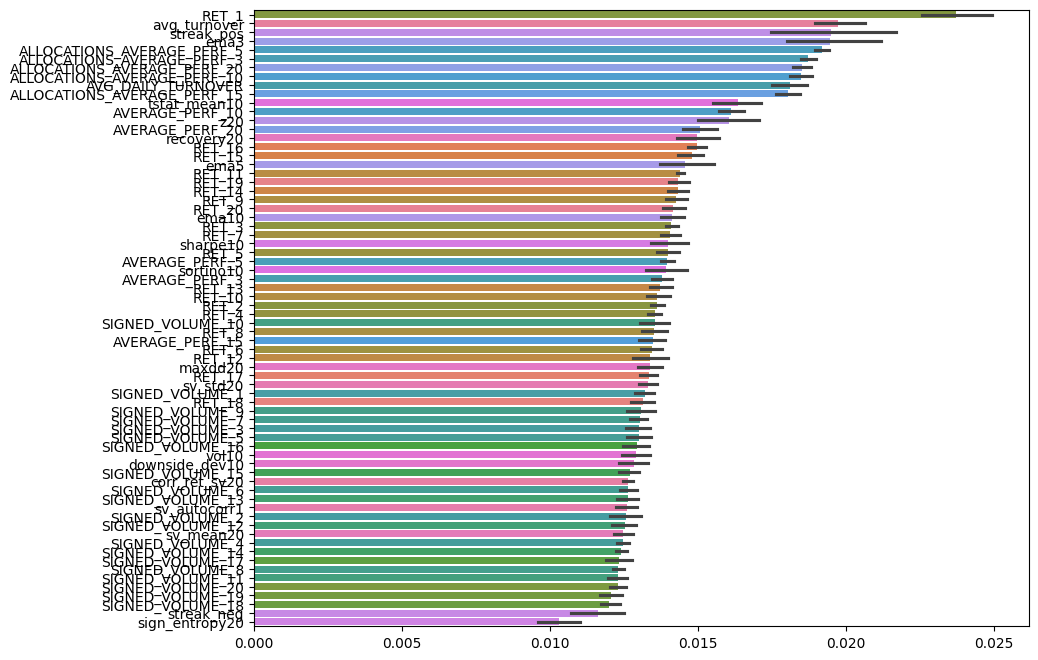

In [48]:
feature_importances = pd.DataFrame([model.feature_importances_ for model in models], columns=features)
plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)



## With linear model

In [72]:

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

for i, (idx_tr_dates, idx_val_dates) in enumerate(kf.split(train_dates), 1):
    tr_dates = train_dates[idx_tr_dates]
    val_dates = train_dates[idx_val_dates]

    m_tr = X_train['TS'].isin(tr_dates)
    m_val = X_train['TS'].isin(val_dates)

    x_tr = X_train.loc[m_tr, features]
    y_tr = y_train_binary.loc[m_tr]
    x_val = X_train.loc[m_val, features]
    y_val = y_train_binary.loc[m_val]

    # sw = None
    # sw = w_tr.loc[m_tr]
   

    clf = xgb.XGBClassifier(
    booster="gblinear",
    objective="binary:logistic",
    eval_metric="logloss",

    # régularisation (à tuner)
    reg_lambda=10.0,     # L2 (type Ridge) 5–100 à tester
    reg_alpha=0.2,       # >0 pour Elastic Net (ex. 0.1–1.0)

    # itérations / pas
    n_estimators=2000,   # nb d’updates linéaires
    learning_rate=0.1,   # 0.05–0.5 à tester

    random_state=42,
    early_stopping_rounds=100,
    n_jobs=-1
)

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models.append(clf)
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


Fold 01 - Acc: 51.37% | best_iter=0 | best_logloss=0.6930670734954659
Fold 02 - Acc: 50.14% | best_iter=0 | best_logloss=0.6931459249484321
Fold 03 - Acc: 50.02% | best_iter=143 | best_logloss=0.6931614908185134
Fold 04 - Acc: 49.56% | best_iter=150 | best_logloss=0.6932371905100938
Fold 05 - Acc: 50.53% | best_iter=123 | best_logloss=0.6931077950995884
Fold 06 - Acc: 49.22% | best_iter=0 | best_logloss=0.6933045294045806
Fold 07 - Acc: 51.06% | best_iter=0 | best_logloss=0.6930734879604414
Fold 08 - Acc: 49.52% | best_iter=0 | best_logloss=0.6932409473109067
Fold 09 - Acc: 51.32% | best_iter=0 | best_logloss=0.6930670679294212
Fold 10 - Acc: 49.99% | best_iter=104 | best_logloss=0.693166127293615
Accuracy: 50.27% [49.54 ; 51.00] (±0.73)


# Alloc embedding with clustering

## With alloc embedding with SVD

In [57]:

class AllocationSVDEmbedder:
    def __init__(self, k=5, ts_col="TS", alloc_col="ALLOCATION", value_col="pivot_cs"):
        self.k, self.ts_col, self.alloc_col, self.value_col = k, ts_col, alloc_col, value_col
        self.alloc_order_ = None
        self.embeddings_ = None
        self.zero_ = None

    def _make_matrix(self, df):
        M = df.pivot(index=self.ts_col, columns=self.alloc_col, values=self.value_col)
        M = M.sort_index(axis=0).sort_index(axis=1)
        # centrage par TS pour enlever le mode commun du jour
        M = M.sub(M.mean(axis=1), axis=0).fillna(0.0)
        # standardisation par allocation (col)
        col_std = M.std(axis=0, ddof=0).replace(0, 1.0)
        M = M / col_std
        return M

    def fit(self, df_train: pd.DataFrame):
        M = self._make_matrix(df_train)
        U, S, Vt = np.linalg.svd(M.to_numpy(), full_matrices=False)
        Vtk = Vt[:self.k, :]                    # (k, n_alloc)
        Sk = S[:self.k]                         # (k,)
        E = (Vtk.T * Sk)                        # (n_alloc, k) -> alloc coords = V Σ
        self.alloc_order_ = M.columns.to_list()
        self.embeddings_ = pd.DataFrame(E, index=self.alloc_order_,
                                        columns=[f"alloc_svd_{i+1}" for i in range(self.k)])
        self.zero_ = np.zeros(self.k, dtype=float)
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        if self.embeddings_ is None:
            raise RuntimeError("Call fit() first.")
        emb = self.embeddings_
        vals = df[self.alloc_col].map(lambda a: emb.loc[a].to_numpy() if a in emb.index else self.zero_)
        X = np.vstack(vals.to_list())
        for i in range(self.k):
            df[f"alloc_svd_{i+1}"] = X[:, i]
        return df

    def fit_transform(self, df_train: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df_train).transform(df_train.copy())


In [ ]:
if "pivot_cs" not in X_train.columns:
    # ex: moyenne des 10 derniers retours; remplace par z20/sharpe10 si déjà calculé
    ret_cols_10 = [f"RET_{i}" for i in range(1, 11)]
    X_train["pivot_cs"] = X_train[ret_cols_10].mean(axis=1)

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

train_dates = X_train['TS'].unique()
scores, models, best_rounds, best_scores = [], [], [], []
embedders = []  # (optionnel) pour réutiliser sur test ensuite

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

for i, (idx_tr_dates, idx_val_dates) in enumerate(kf.split(train_dates), 1):
    tr_dates = train_dates[idx_tr_dates]
    val_dates = train_dates[idx_val_dates]

    m_tr = X_train['TS'].isin(tr_dates)
    m_val = X_train['TS'].isin(val_dates)

    # --- SVD embedding (fit sur TRAIN du fold uniquement) ---
    embedder = AllocationSVDEmbedder(
        k=5, ts_col="TS", alloc_col="ALLOCATION", value_col="pivot_cs"
    )
    df_fit = X_train.loc[m_tr, ["TS", "ALLOCATION", "pivot_cs"]]
    embedder.fit(df_fit)

    # on transforme des DF ne contenant que TS/ALLOCATION pour récupérer alloc_svd_*
    df_tr_ids  = X_train.loc[m_tr, ["TS", "ALLOCATION"]].copy()
    df_val_ids = X_train.loc[m_val, ["TS", "ALLOCATION"]].copy()
    df_tr_emb  = embedder.transform(df_tr_ids)
    df_val_emb = embedder.transform(df_val_ids)
    emb_cols = [c for c in df_tr_emb.columns if c.startswith("alloc_svd_")]

    # --- Features finales du fold = features existantes + embeddings ---
    x_tr_base = X_train.loc[m_tr, features].reset_index(drop=True)
    x_val_base = X_train.loc[m_val, features].reset_index(drop=True)
    x_tr = pd.concat([x_tr_base, df_tr_emb[emb_cols].reset_index(drop=True)], axis=1)
    x_val = pd.concat([x_val_base, df_val_emb[emb_cols].reset_index(drop=True)], axis=1)

    y_tr = y_train_binary.loc[m_tr].reset_index(drop=True)
    y_val = y_train_binary.loc[m_val].reset_index(drop=True)

    # --- Modèle ---
    clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=100,
        n_jobs=-1
    )

    clf.fit(X=x_tr, y=y_tr, eval_set=[(x_val, y_val)], verbose=False)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    models.append(clf)
    embedders.append(embedder)  # (optionnel) pour servir le set test plus tard
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")

Fold 01 - Acc: 53.14% | best_iter=89 | best_logloss=0.690110158834526
Fold 02 - Acc: 53.16% | best_iter=56 | best_logloss=0.6901046501102537
Fold 03 - Acc: 52.27% | best_iter=16 | best_logloss=0.6917868491820888
Fold 04 - Acc: 51.81% | best_iter=41 | best_logloss=0.6917991595859496
Fold 05 - Acc: 53.68% | best_iter=38 | best_logloss=0.6898246346050354
Fold 06 - Acc: 51.32% | best_iter=10 | best_logloss=0.6926667100321879
Fold 07 - Acc: 52.86% | best_iter=39 | best_logloss=0.6906095113101451
Fold 08 - Acc: 52.51% | best_iter=44 | best_logloss=0.6914131644516315
Fold 09 - Acc: 52.47% | best_iter=46 | best_logloss=0.6906331044539781
Fold 10 - Acc: 53.26% | best_iter=42 | best_logloss=0.6908456333774026
Accuracy: 52.65% [51.97 ; 53.33] (±0.68)


In [60]:

y_train_binary = (y_train["target"] > 0).astype(int)

if "pivot_cs" not in X_train.columns:
    ret_cols_10 = [f"RET_{i}" for i in range(1, 11)]
    X_train["pivot_cs"] = X_train[ret_cols_10].mean(axis=1)

embedder = AllocationSVDEmbedder(k=5, ts_col="TS", alloc_col="ALLOCATION", value_col="pivot_cs")
embedder.fit(X_train[["TS", "ALLOCATION", "pivot_cs"]])

tr_ids  = X_train[["TS", "ALLOCATION"]].copy()
te_ids  = X_test[["TS", "ALLOCATION"]].copy()
tr_emb  = embedder.transform(tr_ids)
te_emb  = embedder.transform(te_ids)
emb_cols = [c for c in tr_emb.columns if c.startswith("alloc_svd_")]

# 4) Matrices finales
Xtr = pd.concat([X_train[features].reset_index(drop=True), tr_emb[emb_cols].reset_index(drop=True)], axis=1)
Xte = pd.concat([X_test[features].reset_index(drop=True),  te_emb[emb_cols].reset_index(drop=True)], axis=1)
ytr = y_train_binary.reset_index(drop=True)


n_best = int(np.nanmedian(best_rounds))     
clf_final = xgb.XGBClassifier(
    n_estimators=n_best,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)
clf_final.fit(Xtr, ytr)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [68]:
proba_test = clf_final.predict_proba(Xte)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

Y_pred = pd.DataFrame({
    "prediction": pred_test
})

Y_pred.index = X_test.index



In [69]:
Y_pred

,prediction
ROW_ID,
180245,1
180246,0
180247,1
180248,0
180249,0
...,...
187975,1
187976,1
187977,1


In [71]:
Y_pred.to_csv("data/xgb_v2_SVD.csv")

# Model bien fait + alloc embedding 

On va essayer juste PCA sur l'ensemble de l'alloc et sur la date dans le training 

In [21]:

def SVD(A, r):
    X = A - A.mean(axis=0, keepdims=True)      # centre par colonnes
    X = X - X.mean(axis=1, keepdims=True)      # centre par lignes
    # SVD
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    r_use = min(r, S.shape[0])
    S_r = S[:r_use]
    # Ajoute un ratio d'énergie (somme partielle / somme totale)
    energy = S_r.sum() / (S.sum() + 1e-12)
    emb = np.concatenate([S_r, np.array([energy])], axis=0)
    return emb

In [ ]:
def enrich_with_alloc_ts_embeddings(X_train, feature_cols, r= 8):

    df = X_train.copy()

    # par alloc
    alloc_embeddings = {}
    for alloc, g in df.groupby("ALLOCATION", sort=True):
        # Matrice (#TS × #features) pour cette allocation
        # Important : garder un ordre déterministe des TS
        A = g[feature_cols].to_numpy()
        emb = SVD(A, r=r)
        alloc_embeddings[alloc] = emb

    alloc_cols = [f"alloc_svd_{i+1}" for i in range(r)] + ["alloc_svd_ratio"]
    alloc_emb_df = (
        pd.DataFrame.from_dict(alloc_embeddings, orient="index")
        .reset_index()
        .rename(columns={"index": "ALLOCATION"})
    )
    alloc_emb_df.columns = ["ALLOCATION"] + alloc_cols

    # par ts
    ts_embeddings = {}
    for ts, g in df.groupby("TS", sort=True):
        A = g[feature_cols].to_numpy()
        emb = SVD(A, r=r)
        ts_embeddings[ts] = emb

    ts_cols = [f"ts_svd_{i+1}" for i in range(r)] + ["ts_svd_ratio"]
    ts_emb_df = (
        pd.DataFrame.from_dict(ts_embeddings, orient="index")
        .reset_index()
        .rename(columns={"index": "TS"})
    )
    ts_emb_df.columns = ["TS"] + ts_cols

    # merge dans X_train
    df_enriched = (
        df.merge(alloc_emb_df, on="ALLOCATION", how="left")
          .merge(ts_emb_df, on="TS",    how="left")
    )

    return df_enriched


In [46]:
def enrich_with_ts_embeddings(X_train, feature_cols, r= 8):

    df = X_train.copy()

    # par ts
    ts_embeddings = {}
    for ts, g in df.groupby("TS", sort=True):
        A = g[feature_cols].to_numpy()
        emb = SVD(A, r=r)
        ts_embeddings[ts] = emb

    ts_cols = [f"ts_svd_{i+1}" for i in range(r)] + ["ts_svd_ratio"]
    ts_emb_df = (
        pd.DataFrame.from_dict(ts_embeddings, orient="index")
        .reset_index()
        .rename(columns={"index": "TS"})
    )
    ts_emb_df.columns = ["TS"] + ts_cols

    # merge dans X_train
    df_enriched = (
        df.merge(ts_emb_df, on="TS",    how="left")
    )

    return df_enriched


In [98]:
x_temp = enrich_with_ts_embeddings(X_test.fillna(0), features, r=8)

In [88]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

n_splits = 10
#kf = KFold(n_splits=n_splits, shuffle=True, random_state=43)

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

groups = X_train["TS"]  

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
(tr_idx_all, hold_idx) = next(gss.split(X_train, y_train_binary, groups))
X_cv, y_cv = X_train.iloc[tr_idx_all].reset_index(drop=True), y_train_binary.iloc[tr_idx_all].reset_index(drop=True)
X_hold, y_hold = X_train.iloc[hold_idx].reset_index(drop=True), y_train_binary.iloc[hold_idx].reset_index(drop=True)

# OOF et HOLDOUT preds containers
oof_pred = np.full(len(X_cv), np.nan)
hold_preds = []  



gkf = GroupKFold(n_splits=n_splits)


In [89]:
i = 1 
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_cv, y_cv, groups=X_cv["TS"])):
    x_tr, y_tr = X_cv.iloc[tr_idx].copy(), y_cv.iloc[tr_idx].copy()
    x_val, y_val = X_cv.iloc[val_idx].copy(), y_cv.iloc[val_idx].copy()

    # m_tr = X_cv['TS'].isin(tr_dates)
    # m_val = X_cv['TS'].isin(val_dates)

    # x_tr = X_cv.loc[m_tr]
    # y_tr = y_cv.loc[m_tr]
    # x_val = X_cv.loc[m_val]
    # y_val = y_cv.loc[m_val]

    
    r = 8 
    x_tr = enrich_with_alloc_ts_embeddings(x_tr, features)
    x_val = enrich_with_ts_embeddings(x_val, features)
    alloc_features = [f"alloc_svd_{i+1}" for i in range(r)] + ["alloc_svd_ratio"]

    alloc_map = x_tr[["ALLOCATION"] + alloc_features].drop_duplicates("ALLOCATION")

    x_val = x_val.merge(alloc_map, on="ALLOCATION", how="left")
    final_features = [col for col in x_tr.columns if col not in ["TS", "ALLOCATION"]]

    x_tr = x_tr[final_features]
    x_val = x_val[final_features]
   
    clf = xgb.XGBClassifier(
        n_estimators=5000,
        learning_rate=0.04,
        max_depth=4,
        subsample=0.7,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        #reg_alpha=1e-1,
        reg_lambda=5,
        max_bin=256,
        early_stopping_rounds=100,
        n_jobs=-1
    )

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    #HOLD part

    # holdout: ts embeddings recalculés, alloc embeddings importés du train
    x_hold = enrich_with_ts_embeddings(X_hold.copy(), r=r, feature_cols=features)
    x_hold = x_hold.merge(alloc_map, on="ALLOCATION", how="left").fillna(0)

    hold_preds.append(clf.predict_proba(x_hold[final_features])[:, 1])



    models.append(clf)
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

    i+= 1 

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


hold_pred_mean = np.column_stack(hold_preds).mean(axis=1)  # moyenne des K modèles
hold_acc = (hold_pred_mean.round() == y_hold).mean()
print(f"HOLDOUT accuracy (mean of 10 folds): {hold_acc:.4f}")



Fold 01 - Acc: 52.83% | best_iter=74 | best_logloss=0.690791671030338
Fold 02 - Acc: 52.87% | best_iter=85 | best_logloss=0.6911862523720814
Fold 03 - Acc: 52.46% | best_iter=43 | best_logloss=0.6919031486236132
Fold 04 - Acc: 51.85% | best_iter=32 | best_logloss=0.6922295949422396
Fold 05 - Acc: 51.78% | best_iter=22 | best_logloss=0.6920948934518374
Fold 06 - Acc: 52.77% | best_iter=35 | best_logloss=0.6916528377703837
Fold 07 - Acc: 52.32% | best_iter=126 | best_logloss=0.6913756560830007
Fold 08 - Acc: 50.89% | best_iter=41 | best_logloss=0.692003141437963
Fold 09 - Acc: 52.86% | best_iter=128 | best_logloss=0.6911620905655639
Fold 10 - Acc: 51.54% | best_iter=35 | best_logloss=0.6924036532226152
Accuracy: 52.22% [51.58 ; 52.86] (±0.64)
HOLDOUT accuracy (mean of 10 folds): 0.5293


In [90]:
hold_preds = np.column_stack(hold_preds)

# --- vote majoritaire ---
# 1) on transforme chaque proba en prédiction binaire (0/1)
hold_binary = (hold_preds >= 0.5).astype(int)

# 2) on calcule le nombre de votes "1" pour chaque ligne
votes_for_1 = hold_binary.sum(axis=1)

# 3) décision finale = majorité stricte
hold_vote = (votes_for_1 > (hold_binary.shape[1] / 2)).astype(int)

# 4) métrique
hold_acc = (hold_vote == y_hold).mean()
print(f"Holdout accuracy with majority vote: {hold_acc:.4f}")

Holdout accuracy with majority vote: 0.5287


<Axes: >

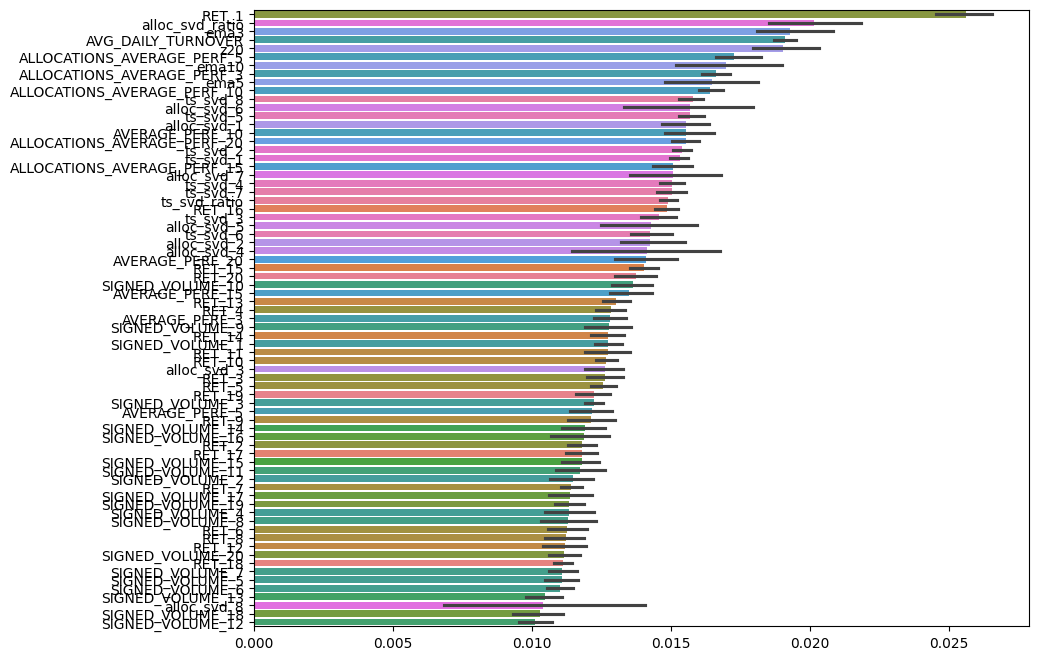

In [93]:
feature_importances = pd.DataFrame([model.feature_importances_ for model in models], columns=final_features)
plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)



# Inference

In [135]:

n_splits = 10
#kf = KFold(n_splits=n_splits, shuffle=True, random_state=43)

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

groups = X_train["TS"]  

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

test_preds = []


gkf = GroupKFold(n_splits=n_splits)

i = 1 
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train_binary, groups=X_train["TS"])):
    x_tr, y_tr = X_train.iloc[tr_idx].copy(), y_train_binary.iloc[tr_idx].copy()
    x_val, y_val = X_train.iloc[val_idx].copy(), y_train_binary.iloc[val_idx].copy()

    # m_tr = X_cv['TS'].isin(tr_dates)
    # m_val = X_cv['TS'].isin(val_dates)

    # x_tr = X_cv.loc[m_tr]
    # y_tr = y_cv.loc[m_tr]
    # x_val = X_cv.loc[m_val]
    # y_val = y_cv.loc[m_val]

    
    r = 8 
    x_tr = enrich_with_alloc_ts_embeddings(x_tr, features)
    x_val = enrich_with_ts_embeddings(x_val, features)
    alloc_features = [f"alloc_svd_{i+1}" for i in range(r)] + ["alloc_svd_ratio"]

    alloc_map = x_tr[["ALLOCATION"] + alloc_features].drop_duplicates("ALLOCATION")

    x_val = x_val.merge(alloc_map, on="ALLOCATION", how="left")
    final_features = [col for col in x_tr.columns if col not in ["TS", "ALLOCATION"]]

    x_tr = x_tr[final_features]
    x_val = x_val[final_features]
   
    base_params = {
        "loss_function": "Logloss",
        "eval_metric": "Logloss",
        "depth": 5,              
        "learning_rate": 0.04,
        "l2_leaf_reg": 10.0,         
        "random_strength": 2.0,        
        "rsm": 0.8,                    
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 2.5,     
        "grow_policy": "Depthwise",    
        "leaf_estimation_method": "Newton",
        "iterations": 10000,
        "early_stopping_rounds": 100,
        "auto_class_weights": "Balanced",
        "use_best_model": True,
        "verbose": 200
    }
    
    clf = CatBoostClassifier(**base_params)

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    clf.fit(**fit_kwargs)

    p_val = clf.predict_proba(x_val)[:, 1]
    acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

    #HOLD part

    # holdout: ts embeddings recalculés, alloc embeddings importés du train
    x_test = enrich_with_ts_embeddings(X_test.copy().fillna(0), r=r, feature_cols=features)
    x_test = x_test.merge(alloc_map, on="ALLOCATION", how="left").fillna(0)

    test_preds.append(clf.predict_proba(x_test[final_features])[:, 1])

    models.append(clf)
    scores.append(acc)
    best_rounds.append(getattr(clf, "best_iteration", None))
    best_scores.append(getattr(clf, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

    i+= 1 

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


test_pred_mean = np.column_stack(test_preds).mean(axis=1)  # moyenne des K modèles




Fold 01 - Acc: 52.70% | best_iter=None | best_logloss=None
Fold 02 - Acc: 52.31% | best_iter=None | best_logloss=None
Fold 03 - Acc: 52.93% | best_iter=None | best_logloss=None
Fold 04 - Acc: 51.97% | best_iter=None | best_logloss=None
Fold 05 - Acc: 53.72% | best_iter=None | best_logloss=None
Fold 06 - Acc: 52.17% | best_iter=None | best_logloss=None
Fold 07 - Acc: 52.19% | best_iter=None | best_logloss=None
Fold 08 - Acc: 52.61% | best_iter=None | best_logloss=None
Fold 09 - Acc: 51.94% | best_iter=None | best_logloss=None
Fold 10 - Acc: 51.95% | best_iter=None | best_logloss=None
Accuracy: 52.45% [51.92 ; 52.98] (±0.53)


In [136]:
test_preds = (test_pred_mean >= 0.5).astype(int)

test_preds_df = pd.DataFrame(test_preds, columns=["prediction"], index = X_test.index)


In [138]:
test_preds_df.to_csv("data/catboost_cv.csv")

# Catboost


In [ ]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold


n_splits = 10
    #kf = KFold(n_splits=n_splits, shuffle=True, random_state=43)

y_train_binary = y_train["target"].apply(lambda x: 1 if x > 0 else 0)

groups = X_train["TS"]  

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=44)
(tr_idx_all, hold_idx) = next(gss.split(X_train, y_train_binary, groups))
X_cv, y_cv = X_train.iloc[tr_idx_all], y_train_binary.iloc[tr_idx_all]
X_hold, y_hold = X_train.iloc[hold_idx], y_train_binary.iloc[hold_idx]

# OOF et HOLDOUT preds containers
oof_pred = np.full(len(X_cv), np.nan)
hold_preds = []  


gkf = GroupKFold(n_splits=n_splits)

def score_holdout_catboost(hp={}):


    base_params = {
        "loss_function": "Logloss",
        "eval_metric": "Logloss",
        "depth": 5,              
        "learning_rate": 0.04,
        "l2_leaf_reg": 10.0,         
        "random_strength": 2.0,        
        "rsm": 0.8,                    
        "bootstrap_type": "Bayesian",
        "bagging_temperature": 2.5,     
        "grow_policy": "Depthwise",    
        "leaf_estimation_method": "Newton",
        "iterations": 10000,
        "early_stopping_rounds": 100,
        "auto_class_weights": "Balanced",
        "use_best_model": True,
        "verbose": 200
    }
    
    for param in hp.keys():
        base_params[param] = hp[param]

    
    i = 1 
    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_cv, y_cv, groups=X_cv["TS"])):
        x_tr, y_tr = X_cv.iloc[tr_idx].copy(), y_cv.iloc[tr_idx].copy()
        x_val, y_val = X_cv.iloc[val_idx].copy(), y_cv.iloc[val_idx].copy()

        r = 8 
        x_tr = enrich_with_alloc_ts_embeddings(x_tr, features)
        x_val = enrich_with_ts_embeddings(x_val, features)
        alloc_features = [f"alloc_svd_{i+1}" for i in range(r)] + ["alloc_svd_ratio"]

        alloc_map = x_tr[["ALLOCATION"] + alloc_features].drop_duplicates("ALLOCATION")

        x_val = x_val.merge(alloc_map, on="ALLOCATION", how="left")
        final_features = [col for col in x_tr.columns if col not in ["TS", "ALLOCATION"]]

        x_tr = x_tr[final_features]
        x_val = x_val[final_features]
    
        clf = CatBoostClassifier(**base_params)

        fit_kwargs = dict(
            X=x_tr, y=y_tr,
            eval_set=[(x_val, y_val)],
            verbose=False,
        )
            
        # fit_kwargs['sample_weight'] = sw

        clf.fit(**fit_kwargs)

        p_val = clf.predict_proba(x_val)[:, 1]
        acc = accuracy_score(y_val, (p_val >= 0.5).astype(int))

        #HOLD part

        # holdout: ts embeddings recalculés, alloc embeddings importés du train
        x_hold = enrich_with_ts_embeddings(X_hold.copy(), r=r, feature_cols=features)
        x_hold = x_hold.merge(alloc_map, on="ALLOCATION", how="left").fillna(0)

        hold_preds.append(clf.predict_proba(x_hold[final_features])[:, 1])



        models.append(clf)
        scores.append(acc)
        best_rounds.append(getattr(clf, "best_iteration", None))
        best_scores.append(getattr(clf, "best_score", None))

        print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

        i+= 1 

    mean = np.mean(scores)*100
    std = np.std(scores)*100
    print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")


    hold_pred_mean = np.column_stack(hold_preds).mean(axis=1)  # moyenne des K modèles
    hold_acc = (hold_pred_mean.round() == y_hold).mean()
    print(f"HOLDOUT accuracy (mean of 10 folds): {hold_acc:.4f}")

    return hold_acc



In [134]:
score_holdout_catboost()

Fold 01 - Acc: 52.85% | best_iter=None | best_logloss=None
Fold 02 - Acc: 52.74% | best_iter=None | best_logloss=None
Fold 03 - Acc: 52.90% | best_iter=None | best_logloss=None
Fold 04 - Acc: 52.59% | best_iter=None | best_logloss=None
Fold 05 - Acc: 52.51% | best_iter=None | best_logloss=None
Fold 06 - Acc: 52.96% | best_iter=None | best_logloss=None
Fold 07 - Acc: 51.12% | best_iter=None | best_logloss=None
Fold 08 - Acc: 52.78% | best_iter=None | best_logloss=None
Fold 09 - Acc: 52.86% | best_iter=None | best_logloss=None
Fold 10 - Acc: 52.42% | best_iter=None | best_logloss=None
Accuracy: 52.58% [52.06 ; 53.09] (±0.51)
HOLDOUT accuracy (mean of 10 folds): 0.5256


np.float64(0.5255672385168788)

In [125]:
hold_preds = np.column_stack(hold_preds)

# --- vote majoritaire ---
# 1) on transforme chaque proba en prédiction binaire (0/1)
hold_binary = (hold_preds >= 0.5).astype(int)

# 2) on calcule le nombre de votes "1" pour chaque ligne
votes_for_1 = hold_binary.sum(axis=1)

# 3) décision finale = majorité stricte
hold_vote = (votes_for_1 > (hold_binary.shape[1] / 2)).astype(int)

# 4) métrique
hold_acc = (hold_vote == y_hold).mean()
print(f"Holdout accuracy with majority vote: {hold_acc:.4f}")

Holdout accuracy with majority vote: 0.5327


# Catboost HP search

# Same with regression xgb

In [140]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

n_splits = 10
#kf = KFold(n_splits=n_splits, shuffle=True, random_state=43)


groups = X_train["TS"]  

train_dates = X_train['TS'].unique()
scores = []
models = []
best_rounds = []
best_scores = []

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
(tr_idx_all, hold_idx) = next(gss.split(X_train, y_train, groups))
X_cv, y_cv = X_train.iloc[tr_idx_all].reset_index(drop=True), y_train.iloc[tr_idx_all].reset_index(drop=True)
X_hold, y_hold = X_train.iloc[hold_idx].reset_index(drop=True), y_train.iloc[hold_idx].reset_index(drop=True)

# OOF et HOLDOUT preds containers
oof_pred = np.full(len(X_cv), np.nan)
hold_preds = []  



gkf = GroupKFold(n_splits=n_splits)


In [ ]:
np.abs(y_val) > 1e-6

In [86]:
(np.abs(y_cv) < 1e-6).mean(), (np.abs(y_hold) < 1e-6).mean()

(target    0.000635
 dtype: float64,
 target    0.000553
 dtype: float64)

In [141]:
i = 1 
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_cv, y_cv, groups=X_cv["TS"])):
    x_tr, y_tr = X_cv.iloc[tr_idx].copy(), y_cv.iloc[tr_idx].copy()
    x_val, y_val = X_cv.iloc[val_idx].copy(), y_cv.iloc[val_idx].copy()

    # m_tr = X_cv['TS'].isin(tr_dates)
    # m_val = X_cv['TS'].isin(val_dates)

    # x_tr = X_cv.loc[m_tr]
    # y_tr = y_cv.loc[m_tr]
    # x_val = X_cv.loc[m_val]
    # y_val = y_cv.loc[m_val]

    
    # r = 8 
    # x_tr = enrich_with_alloc_ts_embeddings(x_tr, features)
    # x_val = enrich_with_ts_embeddings(x_val, features)
    # alloc_features = [f"alloc_svd_{i+1}" for i in range(r)] + ["alloc_svd_ratio"]

    # alloc_map = x_tr[["ALLOCATION"] + alloc_features].drop_duplicates("ALLOCATION")

    #x_val = x_val.merge(alloc_map, on="ALLOCATION", how="left")
    
    final_features = [col for col in x_tr.columns if col not in ["TS", "ALLOCATION"]]

    x_tr = x_tr[final_features]
    x_val = x_val[final_features]
   
    model = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.8,
    objective="reg:squarederror",  
    eval_metric="mae",           
    tree_method="hist",
    random_state=42,
    reg_lambda=15,
    max_bin=256,
    n_jobs=-1,
    early_stopping_rounds=100, 
)

    fit_kwargs = dict(
        X=x_tr, y=y_tr,
        eval_set=[(x_val, y_val)],
        verbose=False,
    )
        
    # fit_kwargs['sample_weight'] = sw

    model.fit(**fit_kwargs)

    p_val = model.predict(x_val)
    acc = (np.sign(p_val) == np.sign(y_val.to_numpy())).mean()

    #HOLD part

    # holdout: ts embeddings recalculés, alloc embeddings importés du train
    # x_hold = enrich_with_ts_embeddings(X_hold.copy(), r=r, feature_cols=features)
    # x_hold = x_hold.merge(alloc_map, on="ALLOCATION", how="left").fillna(0)

    hold_preds.append(model.predict(x_hold[final_features]))


    models.append(model)
    scores.append(acc)
    best_rounds.append(getattr(model, "best_iteration", None))
    best_scores.append(getattr(model, "best_score", None))

    print(f"Fold {i:02d} - Acc: {acc*100:.2f}% | best_iter={best_rounds[-1]} | best_logloss={best_scores[-1]}")

    i+= 1 

mean = np.mean(scores)*100
std = np.std(scores)*100
print(f"Accuracy: {mean:.2f}% [{(mean-std):.2f} ; {(mean+std):.2f}] (±{std:.2f})")



# hold_preds : np.array shape (n_holdout, K)
hold_preds = np.column_stack(hold_preds)

hold_pred_mean = hold_preds.mean(axis=1)
hold_acc_mean = (np.sign(hold_pred_mean) == np.sign(y_hold)).mean()


hold_signs = np.sign(hold_preds)
votes_sum = hold_signs.sum(axis=1)
hold_vote = np.sign(votes_sum)
hold_acc_vote = (hold_vote == np.sign(y_hold)).mean()

print(f"HOLDOUT sign accuracy (mean of 10 folds): {hold_acc_mean:.4f}")
print(f"HOLDOUT sign accuracy (majority vote of 10 folds): {hold_acc_vote:.4f}")




Fold 01 - Acc: 50.01% | best_iter=124 | best_logloss=0.00112312789636801
Fold 02 - Acc: 50.00% | best_iter=112 | best_logloss=0.00109577720484502
Fold 03 - Acc: 49.94% | best_iter=136 | best_logloss=0.00115227749415156


KeyboardInterrupt: 